In [1]:
import torch
torch.__version__

'2.5.1+cu124'

In [2]:
import numpy as np
import torch

torch.set_printoptions(edgeitems=2, threshold=50)

In [ ]:
"""
使用 imageio 模块中的 volread() 函数加载一个 CT 扫描样本, 该函数接受将目录作为参数,
并将所有医学数字成像和通信(Digital Imaging and Communication in Medicine, DICOM) 文件汇编为一个 NumPy 三维数组

从癌症影像档案(Cancer Imaging Archive)的 CPTAC-LSCC 收集.
"""
import imageio

# dir_path = "../data/p1ch4/volumetric-dicom/2-LUNG 3.0  B70f-04083"
dir_path = "./data/p1ch4/volumetric-dicom/2-LUNG 3.0  B70f-04083"
vol_arr = imageio.volread(dir_path, "DICOM")
vol_arr.shape

Reading DICOM (examining files): 1/99 files (1.0%)99/99 files (100.0%)
  Found 1 correct series.
Reading DICOM (loading data): 82/99  (82.8%)99/99  (100.0%)


(99, 512, 512)

In [ ]:
vol = torch.from_numpy(vol_arr).float()
# 由于没有通道信息, 布局与 PyTorch 期望的不同. 所以我们必须使用 unsqueeze()为通道维度留出空间.
# 一个 5 维的张量, 形状为 N x C x D x H x W. 批次 x 通道 x 深度 x 高度 x 宽度
vol = torch.unsqueeze(vol, 0)

vol.shape

torch.Size([1, 99, 512, 512])

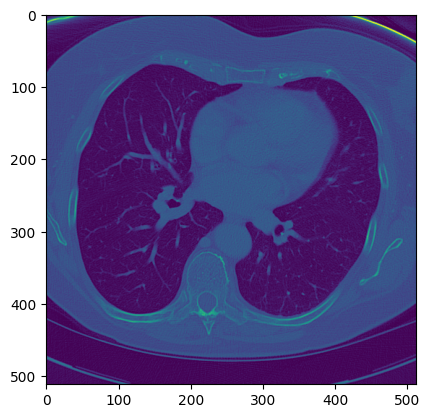

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(vol_arr[50])